In [136]:
import math
from dataclasses import dataclass
from typing import Dict, Tuple, Callable
import numpy as np

In [69]:
class ODEState:
    def __init__(
            self,
            t: float,
            y: Tuple[float, ...]
    ):
        self.t= t
        self.y= y



In [70]:
class DifferentialEquation:
    def __init__(
            self,
            derivative: Callable[[float, Tuple[float, ...]], Tuple[float, ...]],
            initial_time: float,
            initial_state: Tuple[float,...],
    ):
        self.derivative = derivative
        self.initial_time = initial_time
        self.initial_state = initial_state


    def evaluate(
            self,
            t: float,
            state: Tuple[float, ...]
    ):
        return self.derivative(t, state)

In [ ]:
class ODESolver:
    def __init__(
            self,
            ode: DifferentialEquation,
            step_size: float,
    ):
        self.ode = ode
        self.step_size = step_size

    def step(
            self,
            state: ODEState,
            step_size: float
    ) -> ODEState:
        raise NotImplementedError("This method should be implemented by subclasses.")

    def solve(
            self,
            final_time: float
    ) -> list[ODEState]:
        
        state = ODEState(
            t = self.ode.initial_time,
            y= self.ode.initial_state
        )

        states = [state]

        while state.t < final_time:
            remaining_time = final_time-state.t
            step_size=min(self.step_size,remaining_time)


            state = self.step(
                state,
                step_size
            )
            states.append(state)

        return states

In [72]:
class EulerMethod(ODESolver):

    def step(
            self,
            state: ODEState,
            step_size: float,
    )-> ODEState:

        t = state.t
        y = state.y

        dydt = self.ode.evaluate(t, y)

        next_y = tuple(
            yi + step_size * dyi
            for yi, dyi in zip(y, dydt)
        )

        return ODEState(
            t + step_size,
            next_y
        )

    

In [81]:
class SimulationEngine:
    """
    Orchestrates the numerical solution of the differential equation.
    """

    def __init__(self, solver: ODESolver):
        self.solver = solver

    def run(self, final_time: float) -> list[ODEState]:
        return self.solver.solve(final_time)

In [175]:
def derivative(
    t: float,
    state: Tuple[float, ...]
) -> Tuple[float, ...]:
    x, velocity = state

    mu = 1.0

    dx_dt = velocity
    dvelocity_dt = (
        mu * (1 - x**2) * velocity
        - x
    )

    return (
        dx_dt,
        dvelocity_dt,
    )


edo = DifferentialEquation(
    derivative=derivative,
    initial_time=0.0,
    initial_state=(2.0, 0.5),
)

In [182]:

solver = EulerMethod(
    edo,
    step_size=0.001
)

engine = SimulationEngine(solver)

solution = engine.run(
    final_time=30
)


times = [state.t for state in solution]
positions = [state.y[0] for state in solution]
velocities = [state.y[1] for state in solution]


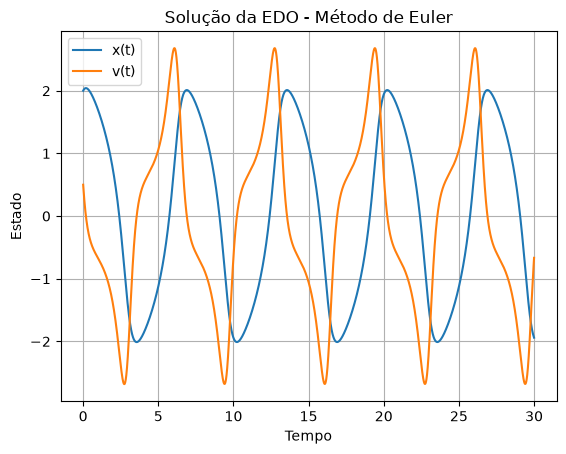

In [183]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    times,
    positions,
    label="x(t)"
)

plt.plot(
    times,
    velocities,
    label="v(t)"
)

plt.xlabel("Tempo")
plt.ylabel("Estado")

plt.title(
    "Solução da EDO - Método de Euler"
)

plt.grid()
plt.legend()

plt.show()

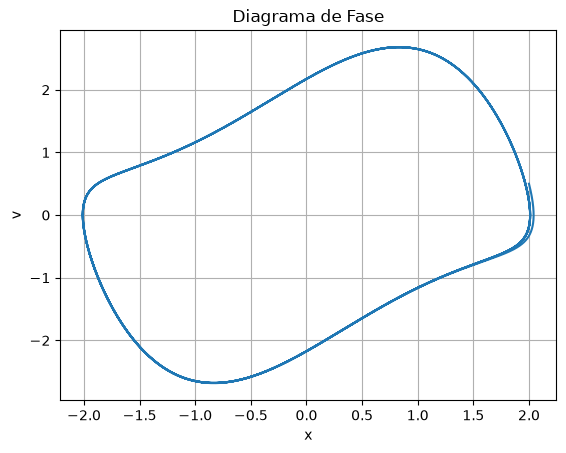

In [184]:
plt.figure()

plt.plot(
    positions,
    velocities
)

plt.xlabel("x")
plt.ylabel("v")

plt.title("Diagrama de Fase")

plt.grid()

plt.show()